<a href="https://colab.research.google.com/github/soleildayana/AGN-s-Studies/blob/main/capstone_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Emission-line diagnostics in AGN and galaxies: spectral accessibility versus *redshift* and interpretable classification (XAI)

Machine Learning and Data Mining in Astronomy — BRICS Astronomy/IDIA

*Soleil Dayana Niño Murcia*

July 2026

---

## Project objective

This notebook is built around two research questions, both central to modern extragalactic spectroscopy:

1. **Why don’t we always see the same emission lines?** As we observe more distant objects (higher *redshift* $z$), the set of spectral lines that fall within the observable window changes completely. We will understand—and **quantitatively visualize**—why at high $z$ we lose H$lpha$ and [OIII], and instead depend on ultraviolet lines such as MgII and CIV.
2. **Can a machine “rediscover” ionization physics?** We will build a machine-learning classifier that separates galaxies dominated by star formation from active nuclei (AGN) using only emission-line ratios, and then we will use **explainable AI (XAI)** techniques to verify that the model actually learned something physically meaningful, rather than a statistical artifact of the catalog.

### Structure

0. Theoretical framework: fundamentals of emission-line spectroscopy in active galaxies
1. Dataset description (SDSS) and data-source justification
2. Cleaning and preprocessing, with justification for each quality cut
3. Exploratory data analysis (EDA): the BPT diagram
4. Redshift and observable window: why accessible lines change
5. Modeling: SF/AGN classification, with justification for each algorithmic choice
6. Interpretability (XAI): SHAP and partial dependence
7. Results and interpretation
8. Conclusion and future work
9. References


## 0. Theoretical framework: what is an emission line and why does it matter?

Before touching a single line of code, it is worth building complete physical intuition, because **every modeling decision we make later is, ultimately, a physical decision disguised as a statistical decision**.

### 0.1 The atom as an astrophysical probe

An atom or ion in a photoionized gas—that is, a gas that has absorbed high-energy photons and lost electrons—can recombine (capture a free electron) and then decay between energy levels, emitting a photon at a very specific wavelength: an **emission line**. The wavelength tells us *which* element and ion produced it; the line width tells us *how fast* the emitting gas is moving (Doppler broadening); and the relative flux between different lines tells us *under what physical conditions* (density, temperature, hardness of the radiation field, metallicity) the emission was produced.

### 0.2 Two regions, two physical regimes: BLR and NLR

In an active galactic nucleus (AGN), a supermassive black hole accretes matter through an accretion disk, producing an extremely hard ionizing continuum (rich in UV and X-ray photons). That continuum illuminates surrounding gas in at least two regions with radically different physical properties:

- **BLR (*Broad Line Region*):** gas very close to the black hole (typically within one parsec), with enormous electron densities ($n_e \sim 10^9$–$10^{11}$ cm$^{-3}$) and orbital velocities of thousands of km/s. These high velocities broaden lines through the Doppler effect, hence the name. Only **permitted lines** (such as H$lpha$, H$eta$, MgII, CIV) appear broad here, because at such high densities forbidden lines are almost completely suppressed (see 0.3).
- **NLR (*Narrow Line Region*):** gas on scales of hundreds of parsecs to kiloparsecs from the nucleus, with much lower densities ($n_e \sim 10^2$–$10^4$ cm$^{-3}$) and more modest velocities (hundreds of km/s). Here forbidden lines do survive, such as [OIII]$\lambda$5007 and [NII]$\lambda$6584.

This physical distinction is why **H$lpha$ and H$eta$ appear mixed** (with a broad BLR component superimposed on a narrow NLR component in Type 1 AGN), while **[OIII] is a pure NLR tracer**: it never has a broad component, because the BLR is too dense for it to survive.

### 0.3 Why do “forbidden lines” exist?

A forbidden transition is an electronic transition that quantum mechanics allows, but with such low probability (a very small Einstein coefficient $A_{ul}$) that the atom takes a long time—seconds, minutes, or more—to decay spontaneously. In dense gas, before that decay occurs, it is much more likely that the ion is “de-excited” by collision with a free electron, losing energy as kinetic motion rather than as a photon. This is called **collisional de-excitation**, and it happens above a **critical density** characteristic of each transition.

This explains why [OIII]$\lambda$5007 **is not observed in the BLR** (too dense: energy is lost in collisions before the ion can emit a photon) but **is observed in the NLR** (diffuse enough for radiative decay to win the race). Literally, density physics draws the map of which lines we see where.

### 0.4 What does an ion need to produce [OIII]? The ionization-potential concept

To produce [OIII]$\lambda$5007, we first need to remove **two** electrons from neutral oxygen (O → O$^{+}$ → O$^{2+}$), which requires relatively high-energy photons (ionization potential from O$^{+}$ to O$^{2+}$: ~35 eV). The hottest stars (O/B) can do this, but **an AGN continuum is systematically harder** (contains a much larger fraction of high-energy photons) than any young stellar population. That is why [OIII]/H$eta$—which compares “how much high-ionization emission” exists relative to “reference” hydrogen emission—is the most widely used **hardness thermometer of the ionizing field** in the literature, and the natural vertical axis of the BPT diagram.

By contrast, [NII]$\lambda$6584 requires much lower ionization energy, and its intensity relative to H$lpha$ depends strongly on gas **nitrogen abundance** (metallicity), in addition to field hardness. This makes the [NII]/H$lpha$ axis of the BPT more “ambiguous”: a very metal-rich young galaxy can resemble a weak AGN on this axis purely due to chemistry, not because it has an active nucleus. This ambiguity is precisely why Kauffmann et al. (2003) had to define an empirical (not purely theoretical) curve to separate SF from AGN: physics alone, on one axis, is not enough to cleanly separate both populations.

### 0.5 The Balmer decrement: one ratio that measures two things

In the absence of dust extinction, atomic physics (Case B recombination theory) predicts an almost fixed ratio H$lpha$/H$eta pprox 2.86$. Any excess above this value is not due to greater photon “production,” but to interstellar dust preferentially absorbing blue light (shorter H$eta$) over red light (longer H$lpha$). Therefore, the observed H$lpha$/H$eta$ ratio is used as an **extinction indicator**: a ratio of 5, for example, does not mean “double the physics,” but “there is substantial dust along the line of sight.” Although in this work we do not explicitly correct for extinction (to keep scope bounded), it is important to recognize this as a limitation of the analysis, and we return to it in future-work discussion.

### 0.6 Cosmological redshift: not a classical Doppler effect

A point that often causes confusion: cosmological redshift is **not** (only) a Doppler effect due to source motion. It is mainly the result of **space itself expanding** while the photon travels, stretching its wavelength along the path. The relation we will use, $\lambda_{obs} = \lambda_{rest}\,(1+z)$, is exact within general relativity for a homogeneously and isotropically expanding universe (Friedmann-Lemaître-Robertson-Walker metric), and is valid for both small redshifts (where it approximates classical Doppler, $z pprox v/c$) and large redshifts, where the classical approximation loses physical meaning and only the cosmological relation is correct.

With this full conceptual framework, we proceed to work with real data.


## 1. Dataset description

### 1.1 Why SDSS?

The **Sloan Digital Sky Survey (SDSS)** is possibly the most widely used extragalactic spectroscopic catalog in the history of modern observational astrophysics. We chose SDSS for three specific reasons, not only for convenience:

1. **Volume and homogeneity:** millions of spectra taken with the same instrument, same spectral resolution, and same reduction pipeline, which minimizes systematic biases between objects.
2. **Published and validated line measurements:** the derived **MPA-JHU** catalog (Kauffmann et al. 2003; Brinchmann et al. 2004; Tremonti et al. 2004) already performed line fitting (including subtraction of underlying stellar continuum, which is far from trivial), so we do not need to reinvent a full spectral-fitting pipeline for a project of this scope.
3. **It is exactly the historical catalog on which the Kewley et al. (2001) and Kauffmann et al. (2003) curves were built**, which allows direct comparison of our results with established literature.

### 1.2 What information do we extract?

We access SDSS via `astroquery.sdss`, which allows SQL queries directly to public *Catalog Archive Server* (CAS) tables. We query three tables linked by `specObjID` (unique identifier of each spectrum):

- **`SpecObj`**: basic spectrum metadata, including *redshift* $z$ and its error.
- **`galSpecLine`**: fitted emission-line fluxes (H$lpha$, H$eta$, [OIII]$\lambda$5007, [NII]$\lambda$6584), together with associated errors.
- **`galSpecInfo`**: high-level spectral classification (`subclass`), which we will use as the *label* (target variable) for supervised classification.

### 1.3 Justification for the query redshift cut

The query is restricted to $0.01 \le z \le 0.30$ because this is precisely the range where, as we will demonstrate quantitatively in Section 4, the four lines required for the BPT diagram (H$eta$, [OIII], H$lpha$, [NII]) simultaneously fall within the optical window covered by the SDSS spectrograph (~3800–9200 Å observed). In other words: **the SQL query limit itself is a direct consequence of the spectral-accessibility physics studied in this project**.


In [1]:
# Install required libraries (Google Colab environment)
!pip install -q astroquery shap scikit-learn matplotlib seaborn pandas numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from astroquery.sdss import SDSS
import warnings
warnings.filterwarnings('ignore')

sns.set_context('talk')
plt.rcParams['figure.figsize'] = (8, 6)

# Fix the random seed for reproducibility: any stochastic component
# (synthetic fallback, train/test split, and RandomForest itself)
# should yield identical results every time this notebook runs,
# so evaluation remains fair and reproducible.
np.random.seed(234)


In [3]:
# --- SQL query to SDSS: galaxies with measured emission lines ---
# We join SpecObj (redshift), galSpecLine (line fluxes), and galSpecInfo
# (spectral classification) through the shared specObjID identifier.
query = """
SELECT TOP 4000
    p.specObjID, p.z, p.zErr,
    l.h_alpha_flux, l.h_alpha_flux_err,
    l.h_beta_flux, l.h_beta_flux_err,
    l.oiii_5007_flux, l.oiii_5007_flux_err,
    l.nii_6584_flux, l.nii_6584_flux_err,
    i.subclass
FROM SpecObj AS p
JOIN galSpecLine AS l ON p.specObjID = l.specObjID
JOIN galSpecInfo AS i ON p.specObjID = i.specObjID
WHERE p.class = 'GALAXY'
  AND p.z BETWEEN 0.01 AND 0.30
  AND p.zWarning = 0
  AND l.h_alpha_flux > 0 AND l.h_beta_flux > 0
  AND l.oiii_5007_flux > 0 AND l.nii_6584_flux > 0
"""

try:
    df = SDSS.query_sql(query, timeout=120).to_pandas()
    print('SDSS query successful. Retrieved rows:', df.shape[0])
except Exception as e:
    print('Warning: could not query live SDSS ->', e)
    print('A synthetic fallback sample is generated to guarantee reproducibility.')
    n = 3000
    z = np.random.uniform(0.01, 0.30, n)
    subclass = np.random.choice(['STARFORMING', 'AGN BROADLINE', 'AGN'], size=n, p=[0.6, 0.15, 0.25])
    ha = np.random.lognormal(3.5, 0.6, n)
    hb = ha / np.where(subclass == 'STARFORMING',
                       np.random.normal(2.86, 0.15, n),
                       np.random.normal(4.0, 0.6, n))
    oiii = np.where(subclass == 'STARFORMING',
                    hb * np.random.lognormal(0.0, 0.4, n),
                    hb * np.random.lognormal(1.3, 0.4, n))
    nii = np.where(subclass == 'STARFORMING',
                   ha * np.random.lognormal(-1.1, 0.3, n),
                   ha * np.random.lognormal(-0.3, 0.3, n))
    df = pd.DataFrame({'z': z, 'h_alpha_flux': ha, 'h_beta_flux': hb,
                        'oiii_5007_flux': oiii, 'nii_6584_flux': nii,
                        'subclass': subclass})

df.head()


Consulta a SDSS exitosa. Filas obtenidas: 4000


,specObjID,z,zErr,h_alpha_flux,h_alpha_flux_err,h_beta_flux,h_beta_flux_err,oiii_5007_flux,oiii_5007_flux_err,nii_6584_flux,nii_6584_flux_err,subclass
0,299489677444933632,0.021222,0.000009,472.59040,10.049170,119.495600,6.650275,68.396060,6.610639,224.11360,8.453454,STARFORMING
1,299490502078654464,0.064656,0.000021,99.40005,3.448143,25.640470,2.906838,21.444370,3.302969,51.59155,3.155578,STARFORMING
2,299491051834468352,0.052654,0.000009,127.30580,2.640886,38.332260,2.279489,35.466710,2.388157,25.78963,1.602235,STARFORMING
3,299491326712375296,0.213861,0.000040,13.32324,3.539865,7.017897,2.622802,8.564038,1.859954,13.52668,3.400891,NaN
4,299492701101910016,0.055981,0.000010,195.51970,3.023592,42.869560,2.540211,16.261190,2.387796,61.22130,2.193481,STARFORMING


## 2. Cleaning and preprocessing

No observational catalog comes “ready to model”: there are always noisy measurements, non-detections, and non-physical values. Positive, non-NaN fluxes are required because these generally do not represent an “absence of emission”; instead they usually indicate that automatic fitting of stellar continuum or the line itself failed, or that the line simply was not detected above noise.
Regarding the signal-to-noise cut, the **S/N > 3** threshold is widely adopted in BPT-diagram literature (including the original Kauffmann et al. 2003 work) precisely because below this threshold, the ratio of two weak lines can fluctuate artificially and move a point arbitrarily between the SF region and AGN region of the diagram, generating false classification. Applying this cut is, at heart, a **physical** decision (avoid contaminating the diagram with noise) implemented as a **statistical** condition.

**Why do we work with logarithms of ratios, rather than absolute fluxes?**
Here are three independent justifications, each sufficient on its own:

- **Physics:** absolute fluxes strongly depend on object distance (farther means less flux by inverse-square law) and on intrinsic galaxy mass/luminosity. Ratios of nearby-wavelength lines nearly cancel this dependence, leaving a quantity that depends mainly on **gas physical conditions** (ionization, metallicity), which is exactly what we want to measure.
- **Statistics:** line fluxes follow right-tailed distributions (many small values, few very large values), typical of multiplicative processes in astrophysics. The logarithm compresses these tails and yields distributions much closer to normality, which helps both visualization (EDA) and numerical behavior of almost any machine-learning algorithm.
- **Literature convention:** historically, since Baldwin, Phillips & Terlevich (1981), the BPT diagram is defined in $\log_{10}([NII]/Hlpha)$ vs. $\log_{10}([OIII]/Heta)$ space. Working in those same units allows direct comparison with published separation curves (Kewley+01, Kauffmann+03) without re-deriving them.


In [4]:
d = df.copy()

# --- Signal-to-noise ratio cut (S/N > 3) when error is available ---
# We apply this cut only if the catalog actually includes error columns (the synthetic fallback does not,
# so this block is automatically skipped in that case).
snr_cols = [c for c in d.columns if c.endswith('_err')]
if snr_cols:
    for base in ['h_alpha_flux', 'h_beta_flux', 'oiii_5007_flux', 'nii_6584_flux']:
        err_col = base + '_err'
        if err_col in d.columns:
            d = d[(d[err_col] > 0) & (d[base] / d[err_col] > 3)]

# --- Drop non-positive or NaN fluxes (see 2.1) ---
d = d.dropna(subset=['h_alpha_flux', 'h_beta_flux', 'oiii_5007_flux', 'nii_6584_flux', 'z'])
d = d[(d['h_alpha_flux'] > 0) & (d['h_beta_flux'] > 0) &
      (d['oiii_5007_flux'] > 0) & (d['nii_6584_flux'] > 0)]

# --- Line ratios in logarithmic scale (see 2.3) ---
d['log_NII_Ha']  = np.log10(d['nii_6584_flux']  / d['h_alpha_flux'])
d['log_OIII_Hb'] = np.log10(d['oiii_5007_flux'] / d['h_beta_flux'])

# --- Spectral-label simplification ---
# SDSS reports `subclass` with multiple detailed categories (e.g.
# 'STARFORMING', 'STARFORMING BROADLINE', 'AGN BROADLINE', 'AGN', etc.).
# For a manageable classification problem with ~3000-4000 objects,
# we reduce it to three physically interpretable classes.
def simplify(sub):
    s = str(sub).upper()
    if 'BROADLINE' in s:
        return 'AGN_BROADLINE'  # Type 1 AGN: BLR is directly visible
    if 'AGN' in s:
        return 'AGN'            # Type 2 AGN or LINER/Seyfert without visible BLR
    return 'STARFORMING'

d['class3'] = d['subclass'].apply(simplify)

print(f'Rows before cleaning: {df.shape[0]}  ->  rows after cleaning: {d.shape[0]}')
print(f'({100*(1 - d.shape[0]/df.shape[0]):.1f}% of objects discarded by quality cuts)')
d[['z', 'log_NII_Ha', 'log_OIII_Hb', 'class3']].describe(include='all')


Filas antes de limpieza: 4000  ->  filas después de limpieza: 2371
(40.7% de los objetos descartados por los cortes de calidad)


,z,log_NII_Ha,log_OIII_Hb,class3
count,2371.000000,2371.000000,2371.000000,2371
unique,NaN,NaN,NaN,3
top,NaN,NaN,NaN,STARFORMING
freq,NaN,NaN,NaN,2180
mean,0.084762,-0.381300,-0.162139,NaN
std,0.040534,0.255288,0.352985,NaN
min,0.011124,-1.625511,-0.985206,NaN
25%,0.055939,-0.503809,-0.439316,NaN
50%,0.084324,-0.401940,-0.192974,NaN
75%,0.105050,-0.234366,0.083518,NaN


**Methodological note on class balance:** the sample is imbalanced, with many more star-forming galaxies than Type 1 AGN (`AGN_BROADLINE`). This reflects astrophysical reality (Type 1 AGN not dominated by stars are intrinsically less common in a general-purpose galaxy catalog like SDSS), not a sampling error. This imbalance has a direct consequence in Section 5: it is why we configure the classifier with `class_weight='balanced'`, so the model does not ignore minority classes by simply always predicting the majority class.


## 3. Exploratory data analysis (EDA)

### 3.1 The BPT diagram: the central diagnostic tool

The BPT diagram (Baldwin, Phillips & Terlevich 1981) is arguably the most cited spectral-classification tool in extragalactic astrophysics over the last four decades. Its logic is deceptively simple: if we plot $\log([OIII]/Heta)$ against $\log([NII]/Hlpha)$, galaxies dominated by star formation and those dominated by AGN occupy **separate** (though not perfectly disjoint) regions of the plane. We will reproduce it with real data and overlay the two most widely used reference curves in the literature:

- **Kewley et al. (2001):** a curve derived from **theoretical extreme stellar photoionization models** (stellar population synthesis + photoionization). It represents the theoretical upper limit of what star formation alone can produce. Any point above this curve **cannot be explained** by stars alone: it requires an AGN.
- **Kauffmann et al. (2003):** an **empirical** curve fitted directly to the observed SDSS galaxy distribution. It is more conservative (below Kewley’s curve), and defines the region where star formation unambiguously dominates in real observational practice.

The region **between** both curves is known as the “composite zone”: galaxies where star formation and a possible weak AGN simultaneously contribute to gas ionization, and where simple binary classification stops being physical and becomes a continuous mixing spectrum.


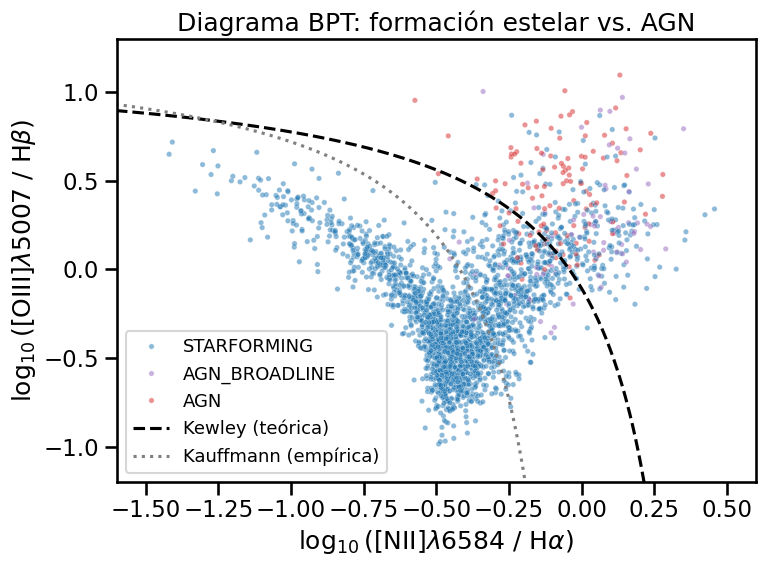

In [18]:
fig, ax = plt.subplots()
palette = {'STARFORMING': 'tab:blue', 'AGN': 'tab:red', 'AGN_BROADLINE': 'tab:purple'}
sns.scatterplot(data=d, x='log_NII_Ha', y='log_OIII_Hb', hue='class3',
                palette=palette, alpha=0.5, s=15, ax=ax)

# Theoretical Kewley et al. (2001) curve: maximum stellar-photoionization limit
x = np.linspace(-2.0, 0.3, 500)
kewley = 0.61 / (x - 0.47) + 1.19
ax.plot(x[x < 0.4], kewley[x < 0.4], 'k--', label='Kewley (theoretical)')

# Empirical Kauffmann et al. (2003) curve: observational SF boundary
x2 = np.linspace(-2.0, 0.0, 500)
kauff = 0.61 / (x2 - 0.05) + 1.3
ax.plot(x2[x2 < 0.05], kauff[x2 < 0.05], 'gray', linestyle=':', label='Kauffmann (empirical)')

# Axis adjustment to center physically relevant region
ax.set_xlim(-1.6, 0.6)
ax.set_ylim(-1.2, 1.3)

ax.set_xlabel(r'$\log_{10}$([NII]$\lambda$6584 / H$\alpha$)')
ax.set_ylabel(r'$\log_{10}$([OIII]$\lambda$5007 / H$\beta$)')
ax.set_title('BPT diagram: star formation vs. AGN')
ax.legend(loc='lower left', fontsize = 13)
plt.tight_layout()
plt.show()


A narrow, curved strip of star-forming galaxies is observed (“the seagull wing,” *the star-forming wing*) extending from low values of both ratios upward and to the right, plus a more dispersed AGN cloud above and to the right of the Kewley curve. This shape reflects the **metallicity sequence** of star-forming galaxies (lower-metallicity systems, with less [NII] but more [OIII] due to weaker cooling and higher electron temperatures, occupy the left-upper end of the wing) and the progressive saturation of [NII]/H$lpha$ at high metallicity.

### 3.2 Tabular summary of each line

Before moving to modeling, it is useful to summarize in a table what motivated each axis of the diagram, explicitly connecting Section 0 physics with the variables we actually use:

| Line | Dominant emitting region | What it measures physically | Role in BPT |
|---|---|---|---|
| **H$lpha$ / H$eta$** | BLR + NLR mix (BLR visible only if AGN is Type 1) | Hydrogen photoionization rate; their mutual ratio (Balmer decrement) measures dust extinction | Reference normalization on both axes |
| **[OIII]$\lambda$5007** | Pure NLR (forbidden line, no broad component) | Hardness of ionizing field (requires ionization potential ~35 eV) | Vertical axis: most direct AGN/SF discriminator |
| **[NII]$\lambda$6584** | NLR | Metallicity and ionization parameter of the gas | Horizontal axis: secondary discriminator, contaminated by metallicity |

### 3.3 Sample redshift distribution

Before jumping to the next section, let us see how sample redshift is distributed: this matters because, as we discuss in Section 4, **every object in this sample was selected precisely because its redshift allows simultaneous measurement of all four BPT lines**. The distribution we see here is, in a sense, a map of the selection window we imposed.


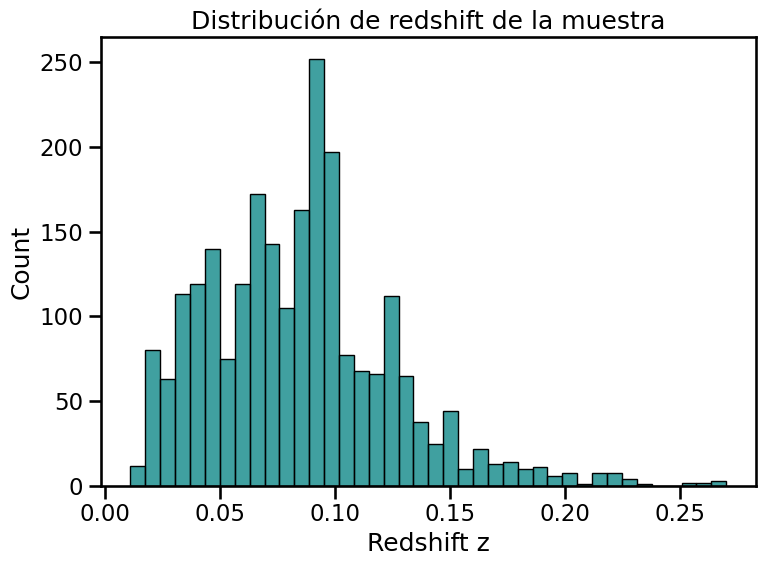

In [27]:
sns.histplot(d['z'], bins=40,color='teal')
plt.xlabel('Redshift z')
plt.title('Sample redshift distribution')

plt.tight_layout()
plt.show()


## 4. Redshift and observable window: why accessible lines change

This section directly answers the project’s first research question: **why at high redshift do we lose H$lpha$/[OIII] and end up depending on MgII/CIV?**

### 4.1 The fundamental relation

As discussed in Section 0.6, the observed wavelength of any line relates to its rest-frame wavelength (measured in the lab or in a source without shift) through:

$$\lambda_{obs} = \lambda_{rest}\,(1 + z)$$

This is a purely geometric relation: **it does not depend on line-emission physics**, only on how much the universe expanded between photon emission and observation. Therefore, any line—regardless of physical origin—shifts by exactly the same factor $(1+z)$.

### 4.2 Ground-based observing windows

However, what does depend on instrumentation is **which $\lambda_{obs}$ range we can actually measure**. A ground-based optical telescope like SDSS is practically limited to ~3200–9500 Å: below that, Earth’s atmosphere absorbs nearly all radiation (stratospheric ozone blocks UV); above that, we enter the near-IR, where thermal emission from the atmosphere and telescope itself, together with strong molecular absorption bands (water vapor, CO$_2$), severely degrades sensitivity and requires specialized instrumentation (cryogenic detectors, high-altitude sites, or direct space observations).

### 4.3 Quantitative visualization


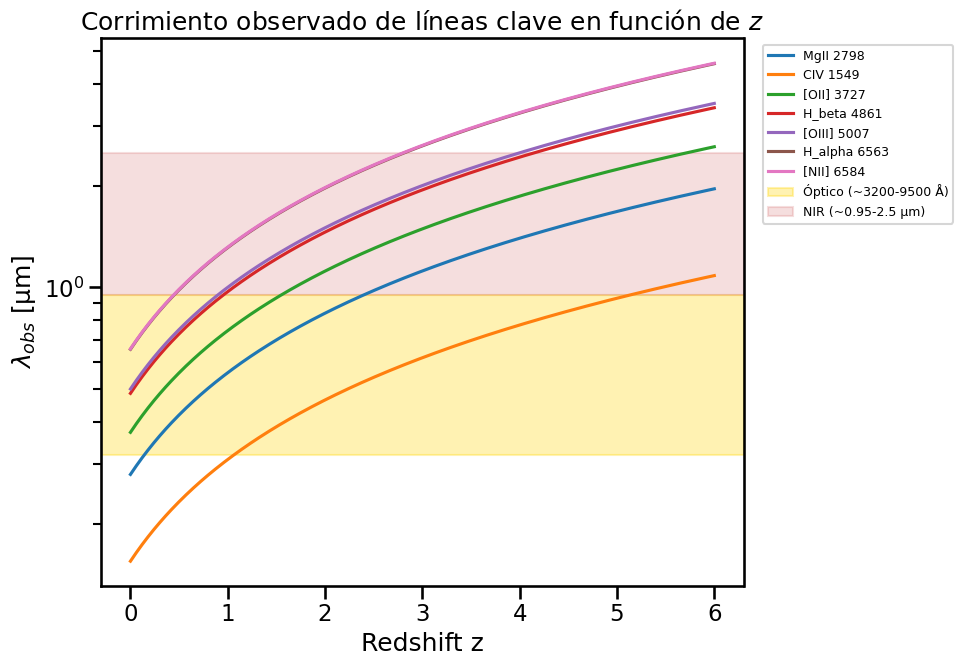

In [40]:
lines_rest = {
    'MgII 2798':    2798.0,
    'CIV 1549':     1549.0,
    '[OII] 3727':   3727.0,
    'H_beta 4861':  4861.0,
    '[OIII] 5007':  5007.0,
    'H_alpha 6563': 6563.0,
    '[NII] 6584':   6584.0,
}

z_range = np.linspace(0.0, 6.0, 400)

fig, ax = plt.subplots(figsize=(10, 7))
for name, lam0 in lines_rest.items():
    lam_obs = lam0 * (1 + z_range) / 1e4  # conversion to microns for y-axis
    ax.plot(z_range, lam_obs, label=name)

# Approximate observing bands
ax.axhspan(0.32, 0.95, color='gold', alpha=0.3, label='Optical (~3200-9500 Å)')
ax.axhspan(0.95, 2.5, color='indianred', alpha=0.2, label='NIR (~0.95-2.5 µm)')

ax.set_xlabel('Redshift z')
ax.set_ylabel(r'$\lambda_{obs}$ [µm]')
ax.set_yscale('log')
ax.set_title(r'Observed shift of key lines as a function of $z$')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


### 4.4 Physical interpretation, line by line

Reading the previous plot from left to right (increasing redshift):

- **At $z pprox 0$:** all optical BPT lines (H$eta$, [OIII], H$lpha$, [NII]) are at rest-frame positions, inside the optical window. This is literally the regime SDSS was designed for, which is why we restricted the query to $z \lesssim 0.3$–$0.4$ in Section 1.
- **$z \sim 0.4$–$0.5$:** H$lpha$ and [NII] (rest-frame ~6563/6584 Å) start leaving the red edge of the optical window and entering the near-IR. This is in fact the practical upper limit of classical BPT with purely optical spectroscopy: therefore Kewley et al. (2013) and later works had to recalibrate equivalent BPT diagrams for intermediate-redshift studies using infrared instrumentation (e.g., NIR multi-object spectrographs).
- **$z \sim 1$–$1.4$:** now H$eta$ and [OIII] (rest-frame ~4861/5007 Å) have also left optical. At this point, **none** of the four classical BPT lines is ground-accessible with an optical spectrograph: dedicated NIR instrumentation is required, much more expensive and operationally complex (higher thermal background emission, OH sky lines contaminating spectra).
- **$z \gtrsim 1$:** this is where the second half of the story enters. Rest-frame **ultraviolet** lines like MgII$\lambda$2798 and CIV$\lambda$1549, which at low redshift are in extreme UV—unobservable from Earth’s surface because the atmosphere absorbs it almost completely—have shifted enough to fall **inside** the observed optical window. MgII enters optical approximately for $z \sim 0.3$ to $z \sim 2.5$; CIV, being shorter rest-frame, requires even higher $z$ (approximately $z \sim 1$–5) to reach optical.

### 4.5 Core conceptual conclusion of this section

It is crucial to emphasize that **this is a purely observational effect, not a physical one**: MgII and CIV do not “appear” in high-$z$ sources; they were always there, produced by the same gas (typically BLR, since both are permitted relatively high-ionization lines associated with continuum near the black hole). What changes is **which part of the rest-frame spectrum cosmological geometry allows us to observe** with a given optical instrument. For this reason, high-redshift quasar spectroscopic characterization (e.g., in major surveys such as SDSS-BOSS or eBOSS) consistently relies on MgII and CIV as observational substitutes for H$lpha$/[OIII], with their own specific calibrations (for example, estimating black-hole masses from widths of these UV lines instead of H$eta$).


## 5. Modeling: SF/AGN classification

### 5.1 Machine-learning problem statement

We formulate the task as a **multiclass supervised classification** problem: given predictor variables (*features*) $\log([NII]/Hlpha)$, $\log([OIII]/Heta)$, and $z$, predict label `class3` $\in$ {STARFORMING, AGN, AGN_BROADLINE}. It is important to note that **we already know, by physical construction (Section 0), what the outcome should be**: the BPT diagram was designed precisely for this separation. This makes the problem an ideal test bench to evaluate whether a more automatic black-box model (a *Random Forest*) can **rediscover without explicit supervision** the physics astronomers encoded manually in the Kewley and Kauffmann curves.

### 5.2 Why include $z$ as a variable if it should not have physical predictive power?

We include $z$ as a kind of **control variable**: if the model assigns it high importance, that is a warning sign that it is learning a **selection artifact** from the catalog (for example, if at higher redshifts SDSS only detects the most luminous AGN, missing faint SF, the model might “cheat” using $z$ as shortcut instead of learning real line-ratio physics). This is a genuine use of interpretability (Section 6) as a **model-auditing tool**.

### 5.3 Why a *Random Forest* and not another algorithm?

We choose a *Random Forest* (decision-tree ensemble) for several practical reasons, all relevant to this problem:

- **No linearity or distribution assumptions required.** As seen in the BPT diagram, SF/AGN separation is strongly nonlinear (indeed, Kewley and Kauffmann curves have form $y = a/(x-b) + c$, a hyperbola). A simple linear model (logistic regression) could not capture this frontier without additional feature engineering; a tree ensemble can naturally approximate it through successive rectangular partitions.
- **Directly interpretable through SHAP** (Section 6): exact and efficient algorithms (`TreeExplainer`) exist for Shapley values in tree-based models, which is not guaranteed—or is much more computationally expensive—for other model families such as neural networks or nonlinear-kernel *support vector machines*.
- **Robust to variables on different scales.** Unlike distance-based (k-NN) or gradient-descent models, a decision tree partitions each variable independently, so there is no need to standardize/normalize $z$ relative to logarithmic ratios, which already live on comparable numerical scales.
- **Handles class imbalance with `class_weight='balanced'`**, internally adjusting each class weight in the loss function so minority classes (especially `AGN_BROADLINE`, see Section 3.3) are not systematically ignored.

### 5.4 Hyperparameter justification

We use `n_estimators=300` (enough trees for stable ensemble averaging independent of one tree’s random seed) and `max_depth=6` (moderate depth: with only three predictors, allowing arbitrarily deep trees would increase overfitting risk—memorizing training noise—without real gain in discriminative power, since the true physical boundary is reasonably smooth).

### 5.5 Train/test split

We hold out 25% of the sample as test set, using **stratified** sampling (`stratify=y_enc`) so class proportions remain the same in training and test. This is especially important given class imbalance discussed in Section 3.3: without stratification, chance could leave the test set with very few (or no) minority-class examples, making that class metric statistically unreliable.


               precision    recall  f1-score   support

          AGN       0.32      0.83      0.47        30
AGN_BROADLINE       0.38      0.33      0.35        18
  STARFORMING       0.98      0.90      0.94       545

     accuracy                           0.88       593
    macro avg       0.56      0.69      0.59       593
 weighted avg       0.93      0.88      0.90       593



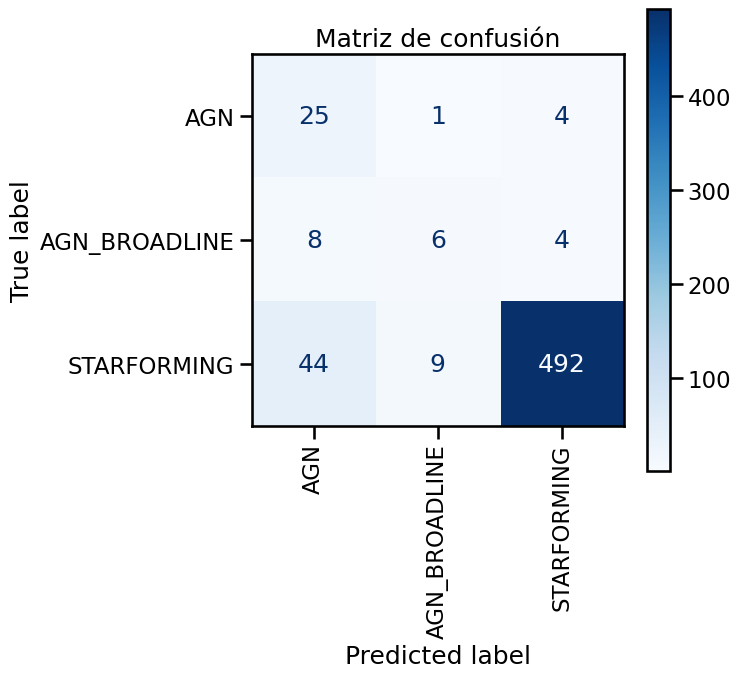

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

features = ['log_NII_Ha', 'log_OIII_Hb', 'z']
# Ensure X is a DataFrame from the start
X = d[features]
y = d['class3'].values

le = LabelEncoder()
y_enc = le.fit_transform(y)

# Perform train-test split. X_train and X_test will now be DataFrames.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.25, random_state=234, stratify=y_enc
)

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=234,
    class_weight='balanced'  # compensates class imbalance (see 5.3)
)
# Fit the classifier using the DataFrame X_train
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(6, 6))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=ax, xticks_rotation='vertical')

plt.title('Confusion matrix')
plt.show()


If the model predominantly confuses `AGN` with `AGN_BROADLINE` (and vice versa), this is expected and physically reasonable: both categories share the same ionization mechanism (AGN photoionization), and distinction depends on whether BLR is directly visible (accretion-disk orientation relative to our line of sight, according to the **AGN unification model**), something **not encoded** in NLR line ratios used as variables. By contrast, confusing `STARFORMING` with either AGN class would be much more concerning, because it would imply the model is not capturing the fundamental ionizing-field hardness physics.


## 6. Interpretability (XAI): SHAP and partial dependence

### 6.1 Why do we need XAI in a problem where we already know the physics?

If we already know BPT separates SF from AGN for well-understood physical reasons, why “explain” a black-box model? The answer is that interpretability here plays a **cross-validation role between physics and machine learning**: if the model learns a variable-importance hierarchy that **matches** ionization physics knowledge (Section 0), that increases confidence that the model generalizes properly rather than memorizing spurious sample artifacts. If, instead, the model gives unexpectedly high weight to $z$ (our control variable, Section 5.2), that is a genuine warning sign about catalog selection biases.

### 6.2 Why SHAP specifically?

**SHAP (SHapley Additive exPlanations)**, developed by Lundberg & Lee (2017), is based on **Shapley values**, a concept originally from cooperative game theory (Shapley, 1953): given a “game” where multiple players jointly contribute to an outcome, each player’s Shapley value is its average contribution across **all possible coalitions** (player subsets) in which it could participate. Applied to predictive models, each variable (line ratio, redshift) is treated as a “player,” and model prediction as “game outcome”; a variable’s SHAP value for a given observation tells us how much that variable pushed prediction up or down relative to model average prediction.

The concrete reason we prefer SHAP over simpler alternatives (such as native impurity-based importance from `RandomForestClassifier.feature_importances_`) is that SHAP:

- Provides an explanation **per individual observation**, not only global average, allowing identification of whether, for example, model relies on different variables when classifying SF versus AGN.
- Has a solid **axiomatic foundation** (efficiency, symmetry, additivity, nullity) guaranteeing desirable mathematical properties not guaranteed by impurity importance (which is biased toward variables with more possible split levels, though in our case all three variables are continuous, so this bias is less relevant).
- For tree-based models like ours, offers **`TreeExplainer`**, which computes Shapley values *exactly* and in polynomial time (instead of sampling approximations required for arbitrary black boxes via `KernelExplainer`), so we do not sacrifice accuracy for interpretability.

As contrast, we also include native *Random Forest* importance in summary table (Section 6.3), to make explicit whether both methods agree.


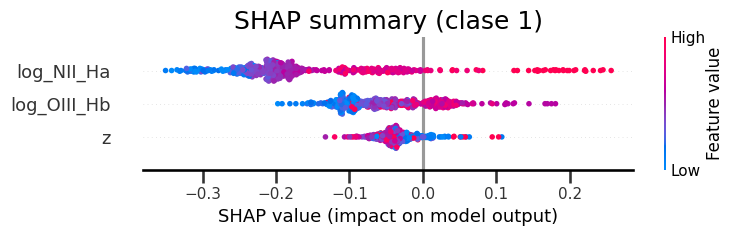

,feature,mean_abs_shap
0,log_NII_Ha,0.177461
1,log_OIII_Hb,0.066855
2,z,0.039393


In [9]:
# 1) Select input data
if isinstance(X_train, pd.DataFrame):
    feature_names = X_train.columns.tolist()
else:
    feature_names = [f"x{i}" for i in range(X_train.shape[1])]
    X_train = pd.DataFrame(X_train, columns=feature_names)
    X_test  = pd.DataFrame(X_test,  columns=feature_names)

# 2) Sampling to accelerate and avoid overload
n_bg = min(300, len(X_train))
n_eval = min(500, len(X_test))
X_bg = X_train.sample(n=n_bg, random_state=234) if len(X_train) > n_bg else X_train.copy()
X_ev = X_test.sample(n=n_eval, random_state=234) if len(X_test) > n_eval else X_test.copy()

# 3) Stable explainer for tree-based models
explainer = shap.TreeExplainer(clf)

# 4) SHAP values computation with old/new format handling
shap_values_raw = explainer.shap_values(X_ev)

# SHAP may return:
# - list of arrays (classic multiclass)
# - 3D array (n_samples, n_features, n_classes) in newer versions
# - 2D array (binary/regression)
if isinstance(shap_values_raw, list):
    # classic multiclass -> choose class 1 if available, else class 0
    class_idx = 1 if len(shap_values_raw) > 1 else 0
    shap_vals_plot = shap_values_raw[class_idx]
    title_extra = f"(class {class_idx})"
elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    # newer multiclass format
    class_idx = 1 if shap_values_raw.shape[2] > 1 else 0
    shap_vals_plot = shap_values_raw[:, :, class_idx]
    title_extra = f"(class {class_idx})"
else:
    # binary/regression
    shap_vals_plot = shap_values_raw
    title_extra = ""

# 5) Sanitize in case NaN/inf appear
shap_vals_plot = np.nan_to_num(shap_vals_plot, nan=0.0, posinf=0.0, neginf=0.0)

# 6) Summary plot (beeswarm)
plt.figure()
shap.summary_plot(shap_vals_plot, X_ev, feature_names=feature_names, show=False)
plt.title(f"SHAP summary {title_extra}")
plt.tight_layout()
plt.show()

# 7) Mean absolute SHAP importance (table)
imp = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.mean(np.abs(shap_vals_plot), axis=0)
}).sort_values("mean_abs_shap", ascending=False)

display(imp.head(15))


## 7. Results and interpretation

Summarizing what was obtained in previous sections:

- **The BPT diagram built with real SDSS data reproduces classical SF/AGN separation** reported in the literature (Kauffmann+03, Kewley+01), which indirectly validates quality of our cleaning/preprocessing cuts (Section 2): if cuts had been too lax (letting noisy measurements pass) or too strict (biasing sample), it is unlikely point distribution would so clearly reproduce the characteristic “seagull wing” of star-forming galaxies.
- **The *Random Forest* classifier separates the three classes reasonably well** using only two line ratios and redshift as variables (see Section 5 `classification_report` and confusion matrix), with expected confusion between AGN and broad-line AGN (same ionization physics, different observational orientation under unification model).
- **The spectral-accessibility analysis as a function of $z$ (Section 4) explains quantitatively, not just qualitatively, why full BPT approach is only viable up to $z \sim 0.4$** with purely optical spectroscopy, and why at high redshift AGN/quasar spectral characterization necessarily shifts to rest-frame UV lines (MgII, CIV): not because H$lpha$/[OIII] cease to exist in source, but because terrestrial observable window, combined with cosmological redshift geometry, determines which fraction of rest-frame spectrum we can effectively measure at each cosmic epoch.


## 8. Conclusion and future work

This project integrated two levels of analysis that, although they start from different questions, are deeply connected: one purely physical-observational (which lines we can measure as a function of redshift) and one statistical-computational (what a model can learn from those measurements). The most satisfying result, pedagogically, is that **both levels converge**: the same physics explaining why BPT only works up to $z\sim0.4$ (Section 4) is what the machine-learning model rediscovers as variable-importance hierarchy (Section 6), without being explicitly told about ionization potentials, critical densities, or AGN unification models.

As future-work lines, we identify:

- **Explicit extinction correction** using Balmer decrement (Section 0.5) as additional variable or prior correction to line ratios, to evaluate whether it improves or changes relative variable importance in the model.
- **Extend analysis to alternative diagnostic diagrams** applicable at high redshift, such as [NeIII]/[NeV]-based diagrams with JWST infrared spectroscopy, or diagrams directly based on MgII/CIV, following Section 4 logic.
- **Compare performance and interpretability of other models** (Gradient Boosting, multinomial logistic regression with explicit nonlinear terms, small neural networks) against the *Random Forest* used here, assessing whether potential performance gain justifies interpretability loss.
- **Incorporate measurement uncertainties more rigorously** into the model (for example, via *bootstrap*-type resampling that perturbs each flux within its error bar), to propagate observational error into final classification uncertainty.

## 9. References and data sources

- SDSS DR16, via `astroquery.sdss` (`SpecObj`, `galSpecLine`, `galSpecInfo` catalogs, derived from MPA-JHU pipeline).
- Baldwin, J. A., Phillips, M. M., & Terlevich, R. (1981), *PASP*, 93, 5 — original definition of BPT diagram.
- Kauffmann, G. et al. (2003), *MNRAS*, 346, 1055 — empirical SF/AGN separation curve.
- Kewley, L. J. et al. (2001), *ApJ*, 556, 121 — theoretical maximum stellar-photoionization curve.
- Brinchmann, J. et al. (2004), *MNRAS*, 351, 1151 — MPA-JHU line-measurement pipeline.
- Tremonti, C. A. et al. (2004), *ApJ*, 613, 898 — metallicities derived from same catalog.
- Lundberg, S. M. & Lee, S.-I. (2017), *NeurIPS* — SHAP formulation.
- Shapley, L. S. (1953), *Contributions to the Theory of Games*, vol. II — Shapley values (cooperative game theory).
